In [ ]:
!pip install gymnasium

   ---------------------------------------- 0.0/965.4 kB ? eta -:--:--
   ---------------------------------------- 965.4/965.4 kB 7.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\Shane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Classical Q-Learning

In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque


# --- Parameters ---
NUM_BINS = (12, 12, 24, 24) # Binning resolution for each state dimension
NUM_EPISODES = 10000
MAX_STEPS = 500
GAMMA = 0.99
ALPHA = 0.3
EPSILON = 1.0
EPSILON_DECAY = 0.999
EPSILON_MIN = 0.01

# --- Environment Setup ---
def create_env():
    return gym.make("CartPole-v1")

# --- State Discretization ---
def create_bins(env, num_bins):
    obs_space = env.observation_space
    bins = []
    for i in range(len(obs_space.low)):
        low = obs_space.low[i]
        high = obs_space.high[i]

        # clip range for stability
        if i == 1:
            low, high = -3.0, 3.0
        elif i == 3:
            low, high = -3.5, 3.5

        bins.append(np.linspace(low, high, num_bins[i] - 1))
    return bins

def discretize(obs, bins):
    state = []
    for i, val in enumerate(obs):
        state.append(np.digitize(val, bins[i]))
    return tuple(state)

# --- Q-Table Initialization ---
def initialize_q_table(num_bins, num_actions):
    return np.zeros(shape=num_bins + (num_actions,))

# --- Epsilon-Greedy Policy ---
def choose_action(q_table, state, epsilon, num_actions):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, num_actions - 1)
    else:
        return np.argmax(q_table[state])

# --- Q-Update Rule ---
def update_q(q_table, state, action, reward, next_state, alpha, gamma):
    best_next = np.max(q_table[next_state])
    q_table[state][action] += alpha * (reward + gamma * best_next - q_table[state][action])

# --- Plotting Function ---
def plot_rewards(episode_rewards, window=100):
    smoothed = []
    for i in range(len(episode_rewards)):
        start = max(0, i - window + 1)
        avg = np.mean(episode_rewards[start:i+1])
        smoothed.append(avg)

    plt.figure(figsize=(12, 6))
    plt.plot(episode_rewards, label="Episode reward")
    plt.plot(smoothed, label=f"{window}-episode moving average", linewidth=3)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Q-Learning Performance on CartPole")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# --- Training Loop ---
def train(env, bins, num_episodes, max_steps):
    q_table = initialize_q_table(tuple(len(b) + 1 for b in bins), env.action_space.n)
    episode_rewards = []
    epsilon = EPSILON

    for episode in range(num_episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)
        total_reward = 0

        for _ in range(max_steps):
            action = choose_action(q_table, state, epsilon, env.action_space.n)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize(next_obs, bins)

            update_q(q_table, state, action, reward, next_state, ALPHA, GAMMA)

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        #epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        if episode < num_episodes * 0.75:
            epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        else:
            epsilon = 0.05  # small but non-zero to maintain exploration

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1}: Total reward = {total_reward}, Epsilon = {epsilon:.3f}")

    plot_rewards(episode_rewards)
    return q_table

# --- Evaluation ---
def evaluate(env, q_table, bins, episodes=10, render=False):
    for ep in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)
        total_reward = 0

        for _ in range(MAX_STEPS):
            if render:
                env.render()
            action = np.argmax(q_table[state])
            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)
            total_reward += reward
            if terminated or truncated:
                break
        print(f"Test Episode {ep + 1}: Total Reward = {total_reward}")

# --- Main ---
if __name__ == "__main__":
    env = create_env()
    bins = create_bins(env, NUM_BINS)
    q_table = train(env, bins, NUM_EPISODES, MAX_STEPS)
    evaluate(env, q_table, bins, episodes=5, render=True)
    env.close()


Episode 100: Total reward = 20.0, Epsilon = 0.905
Episode 200: Total reward = 19.0, Epsilon = 0.819
Episode 300: Total reward = 32.0, Epsilon = 0.741
Episode 400: Total reward = 81.0, Epsilon = 0.670
Episode 500: Total reward = 36.0, Epsilon = 0.606
Episode 600: Total reward = 74.0, Epsilon = 0.549
Episode 700: Total reward = 127.0, Epsilon = 0.496
Episode 800: Total reward = 132.0, Epsilon = 0.449
Episode 900: Total reward = 18.0, Epsilon = 0.406
Episode 1000: Total reward = 132.0, Epsilon = 0.368
Episode 1100: Total reward = 39.0, Epsilon = 0.333
Episode 1200: Total reward = 217.0, Epsilon = 0.301
Episode 1300: Total reward = 117.0, Epsilon = 0.272
Episode 1400: Total reward = 206.0, Epsilon = 0.246
Episode 1500: Total reward = 62.0, Epsilon = 0.223
Episode 1600: Total reward = 170.0, Epsilon = 0.202
Episode 1700: Total reward = 245.0, Epsilon = 0.183
Episode 1800: Total reward = 13.0, Epsilon = 0.165
Episode 1900: Total reward = 276.0, Epsilon = 0.149
Episode 2000: Total reward = 50

KeyboardInterrupt: 

# Classic Q learning using DQN

/usr/local/lib/python3.11/dist-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


Episode 1, Reward = 17.0, Epsilon = 0.995
Episode 2, Reward = 29.0, Epsilon = 0.990
Episode 3, Reward = 13.0, Epsilon = 0.985
Episode 4, Reward = 11.0, Epsilon = 0.980
Episode 5, Reward = 11.0, Epsilon = 0.975
Episode 6, Reward = 35.0, Epsilon = 0.970
Episode 7, Reward = 19.0, Epsilon = 0.966
Episode 8, Reward = 25.0, Epsilon = 0.961
Episode 9, Reward = 52.0, Epsilon = 0.956
Episode 10, Reward = 13.0, Epsilon = 0.951
Episode 11, Reward = 18.0, Epsilon = 0.946
Episode 12, Reward = 26.0, Epsilon = 0.942
Episode 13, Reward = 27.0, Epsilon = 0.937
Episode 14, Reward = 23.0, Epsilon = 0.932
Episode 15, Reward = 27.0, Epsilon = 0.928
Episode 16, Reward = 17.0, Epsilon = 0.923
Episode 17, Reward = 23.0, Epsilon = 0.918
Episode 18, Reward = 12.0, Epsilon = 0.914
Episode 19, Reward = 25.0, Epsilon = 0.909
Episode 20, Reward = 14.0, Epsilon = 0.905
Episode 21, Reward = 21.0, Epsilon = 0.900
Episode 22, Reward = 23.0, Epsilon = 0.896
Episode 23, Reward = 24.0, Epsilon = 0.891
Episode 24, Reward =

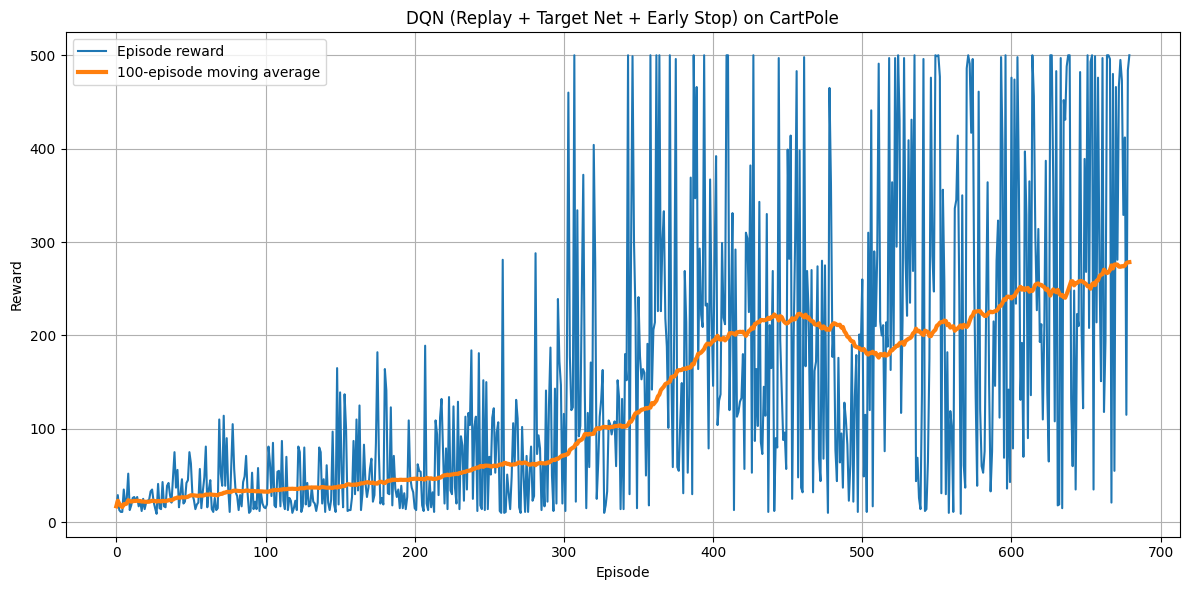

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# Hyperparameters
EPISODES = 2000
MAX_STEPS = 500
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
BUFFER_SIZE = 10000
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
TARGET_UPDATE_FREQ = 5
EARLY_STOP_REWARD = 400
EARLY_STOP_WINDOW = 10

# Replay buffer
class ReplayBuffer:
    def __init__(self, capacity=BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# Deep Q-Network
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# Epsilon-greedy action
def choose_action(model, state, epsilon, output_dim):
    if random.random() < epsilon:
        return random.randint(0, output_dim - 1)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    return model(state).argmax().item()

# Training loop
def train():
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = DQN(input_dim, output_dim)
    target_net = DQN(input_dim, output_dim)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=LR)
    buffer = ReplayBuffer()
    epsilon = EPSILON_START
    rewards = []

    state, _ = env.reset()
    for _ in range(BUFFER_SIZE // 10):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        state = next_state if not done else env.reset()[0]

    for episode in range(EPISODES):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(MAX_STEPS):
            action = choose_action(q_net, state, epsilon, output_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(buffer) >= BATCH_SIZE:
                states, actions, rewards_, next_states, dones = buffer.sample(BATCH_SIZE)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                #with torch.no_grad():
                #    next_q_values = target_net(next_states).max(1)[0]
                #    targets = rewards_ + GAMMA * next_q_values * (1 - dones)

                # Double DQN target: use q_net to select next action, target_net to evaluate
                with torch.no_grad():
                  next_actions = q_net(next_states).argmax(1)
                  next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
                  targets = rewards_ + GAMMA * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
        rewards.append(total_reward)

        print(f"Episode {episode+1}, Reward = {total_reward}, Epsilon = {epsilon:.3f}")

        if episode % TARGET_UPDATE_FREQ == 0:
            target_net.load_state_dict(q_net.state_dict())

        if episode >= EARLY_STOP_WINDOW and np.mean(rewards[-EARLY_STOP_WINDOW:]) >= EARLY_STOP_REWARD:
            print(f"✅ Early stopping at episode {episode+1} with average reward: {np.mean(rewards[-EARLY_STOP_WINDOW:]):.2f}")
            break

        #if (episode + 1) % 100 == 0:
        #    print(f"Episode {episode+1}, Reward = {total_reward}, Epsilon = {epsilon:.3f}")

    env.close()
    return rewards

# Run and plot
rewards = train()
window = 100
moving_avg = [np.mean(rewards[i-window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode reward")
plt.plot(moving_avg, label=f"{window}-episode moving average", linewidth=3)
plt.title("DQN (Replay + Target Net + Early Stop) on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import gymnasium as gym

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(2, activation='softmax')
])

# Create a 4x2 matrix of weights and a 2-element bias vector
weights = [np.array([[1.1454211, 0.75456921], [-0.90695906, -0.14178096], [-0.67663206, -0.90277024], [-2.00805217, -0.16848467]]),np.array([0.0, 0.0])]
model.set_weights(weights)

# Define the input data (4 inputs)
input_data = np.array([[1.0, 2.0, 3.0, 4.0]])

# Predict the outputs
outputs = model.predict(input_data)

print("Model outputs:", outputs)

avgRew = 0
env = gym.make('CartPole-v1')
for i in range(20):
    totalRew = 0
    state = env.reset()[0]
    for i in range(500):
        action = np.argmax(model.predict(np.array([state]), verbose=0)[0])
        state, reward, a, b, _ = env.step(action)
        done = a or b
        totalRew += 1
        if done:
            break
    print(totalRew)
    avgRew += totalRew
print(f'Average over 20 runs: {avgRew/20}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Model outputs: [[4.0171726e-04 9.9959832e-01]]
281
463
400
281
490
435
443
500
500
500
300
394
389
500
383
390
341
359
500
346
Average over 20 runs: 409.75


Episode 1: Reward = 16.0
Episode 2: Reward = 14.0
Episode 3: Reward = 9.0
Episode 4: Reward = 16.0
Episode 5: Reward = 16.0
Episode 6: Reward = 12.0
Episode 7: Reward = 15.0
Episode 8: Reward = 9.0
Episode 9: Reward = 9.0
Episode 10: Reward = 8.0
Episode 11: Reward = 10.0
Episode 12: Reward = 14.0
Episode 13: Reward = 9.0
Episode 14: Reward = 11.0
Episode 15: Reward = 10.0
Episode 16: Reward = 11.0
Episode 17: Reward = 17.0
Episode 18: Reward = 16.0
Episode 19: Reward = 12.0
Episode 20: Reward = 12.0
Episode 21: Reward = 11.0
Episode 22: Reward = 11.0
Episode 23: Reward = 11.0
Episode 24: Reward = 13.0
Episode 25: Reward = 21.0
Episode 26: Reward = 12.0
Episode 27: Reward = 12.0
Episode 28: Reward = 11.0
Episode 29: Reward = 24.0
Episode 30: Reward = 10.0
Episode 31: Reward = 10.0
Episode 32: Reward = 16.0
Episode 33: Reward = 17.0
Episode 34: Reward = 13.0
Episode 35: Reward = 16.0
Episode 36: Reward = 14.0
Episode 37: Reward = 16.0
Episode 38: Reward = 15.0
Episode 39: Reward = 10.0


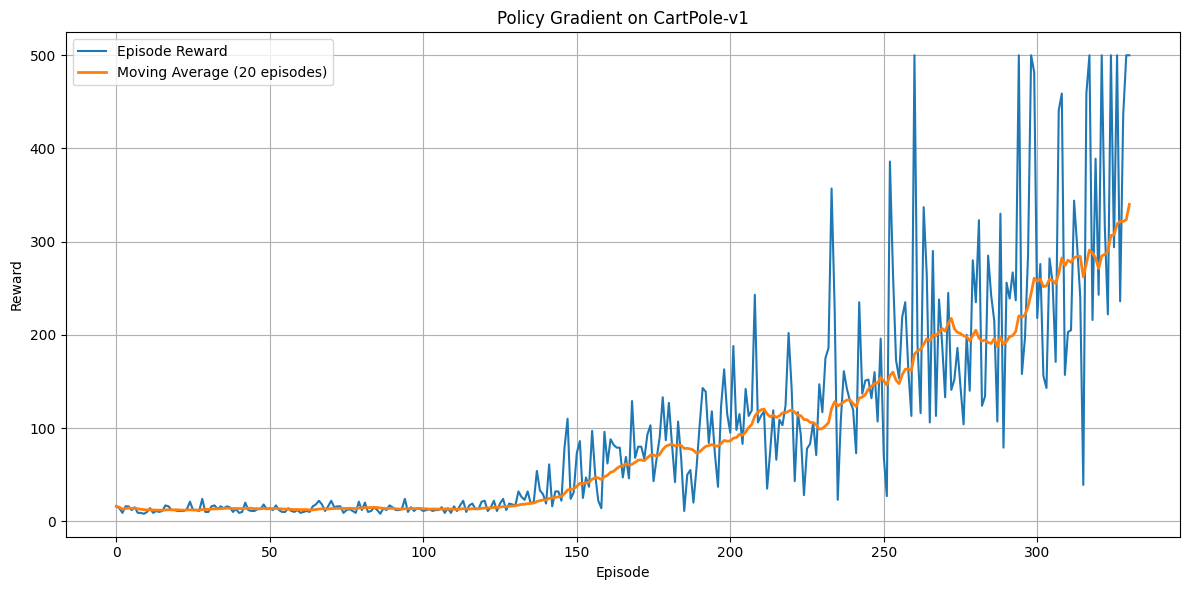

In [ ]:
import tensorflow as tf
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# ==== Define Model ====
# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(4,)),
#     tf.keras.layers.Dense(2, activation='softmax')  # policy output
# ])
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(4, activation='tanh'),     # Hidden layer with 4 units
    tf.keras.layers.Dense(2, activation='softmax')   # Output layer for action probabilities
])


# # OPTIONAL: Set pretrained weights (comment out if you want random init)
# pretrained_weights = [
#     np.array([[1.1454211, 0.75456921],
#               [-0.90695906, -0.14178096],
#               [-0.67663206, -0.90277024],
#               [-2.00805217, -0.16848467]]),
#     np.array([0.0, 0.0])
# ]
# model.set_weights(pretrained_weights)

# ==== Helper Functions ====
def choose_action(state):
    state = state.reshape(1, -1)
    probs = model(state, training=False).numpy()[0]
    return np.random.choice(len(probs), p=probs)

def discount_rewards(rewards, gamma=0.99):
    discounted = np.zeros_like(rewards, dtype=np.float32)
    running_add = 0
    for t in reversed(range(len(rewards))):
        running_add = running_add * gamma + rewards[t]
        discounted[t] = running_add
    return discounted

# ==== Training ====
env = gym.make("CartPole-v1")
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)
all_rewards = []

EPISODES = 2000
for episode in range(EPISODES):
    state, _ = env.reset()
    states, actions, rewards = [], [], []

    for _ in range(500):
        action = choose_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)

        state = next_state
        if done:
            break

    # Compute discounted rewards
    discounted = discount_rewards(rewards)
    discounted -= np.mean(discounted)
    discounted /= (np.std(discounted) + 1e-8)

    # Training step
    with tf.GradientTape() as tape:
        logits = model(np.array(states), training=True)
        neg_log_prob = tf.keras.losses.sparse_categorical_crossentropy(np.array(actions), logits)
        loss = tf.reduce_mean(neg_log_prob * discounted)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    episode_reward = sum(rewards)
    all_rewards.append(episode_reward)
    print(f"Episode {episode+1}: Reward = {episode_reward}")

    # if np.mean(all_rewards[-20:]) >= 475:
    #     print(f"✅ Solved in {episode+1} episodes with avg reward {np.mean(all_rewards[-20:]):.2f}")
    #     break

    # Early stopping if the last 10 episodes average above 400
    if episode >= 10 and np.mean(all_rewards[-10:]) >= 400:
        print(f"✅ Early stopping: Avg reward over last 10 episodes = {np.mean(all_rewards[-10:]):.2f}")
        break


# ==== Plotting ====
moving_avg = [np.mean(all_rewards[max(0, i-20):i+1]) for i in range(len(all_rewards))]

plt.figure(figsize=(12, 6))
plt.plot(all_rewards, label='Episode Reward')
plt.plot(moving_avg, label='Moving Average (20 episodes)', linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Policy Gradient on CartPole-v1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Episode 1: Reward = 11.0
Episode 2: Reward = 31.0
Episode 3: Reward = 12.0
Episode 4: Reward = 21.0
Episode 5: Reward = 12.0
Episode 6: Reward = 11.0
Episode 7: Reward = 30.0
Episode 8: Reward = 18.0
Episode 9: Reward = 10.0
Episode 10: Reward = 36.0
Episode 11: Reward = 13.0
Episode 12: Reward = 19.0
Episode 13: Reward = 12.0
Episode 14: Reward = 15.0
Episode 15: Reward = 15.0
Episode 16: Reward = 25.0
Episode 17: Reward = 29.0
Episode 18: Reward = 40.0
Episode 19: Reward = 40.0
Episode 20: Reward = 11.0
Episode 21: Reward = 40.0
Episode 22: Reward = 42.0
Episode 23: Reward = 13.0
Episode 24: Reward = 68.0
Episode 25: Reward = 17.0
Episode 26: Reward = 47.0
Episode 27: Reward = 13.0
Episode 28: Reward = 20.0
Episode 29: Reward = 96.0
Episode 30: Reward = 16.0
Episode 31: Reward = 25.0
Episode 32: Reward = 14.0
Episode 33: Reward = 11.0
Episode 34: Reward = 35.0
Episode 35: Reward = 20.0
Episode 36: Reward = 9.0
Episode 37: Reward = 15.0
Episode 38: Reward = 13.0
Episode 39: Reward = 1

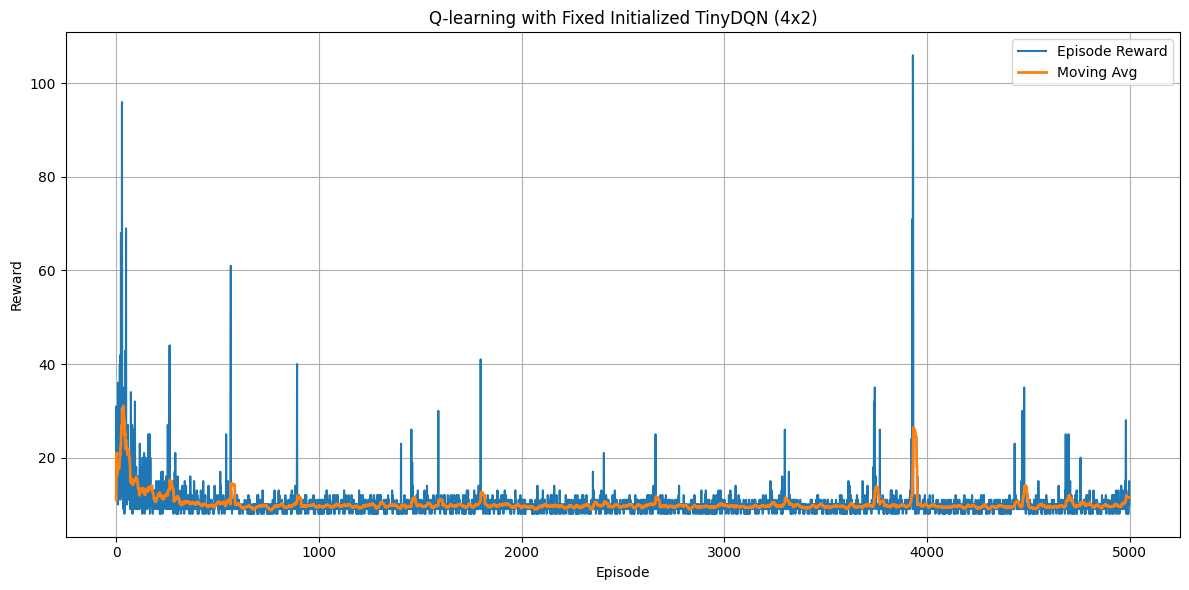

In [ ]:
# Re-import libraries due to kernel reset
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# class TinyDQN(nn.Module):
#     def __init__(self):
#         super(TinyDQN, self).__init__()
#         self.fc = nn.Linear(4, 2, bias=True)
#         with torch.no_grad():
#             # Transpose the weight matrix to match PyTorch's (out_features, in_features)
#             weights = torch.tensor([[1.1454211, 0.75456921],
#                                     [-0.90695906, -0.14178096],
#                                     [-0.67663206, -0.90277024],
#                                     [-2.00805217, -0.16848467]])
#             self.fc.weight.copy_(weights.T)
#             self.fc.bias.zero_()

#     def forward(self, x):
#         return self.fc(x)

# class TinyDQN(nn.Module):
#     def __init__(self):
#         super(TinyDQN, self).__init__()
#         self.fc = nn.Linear(4, 2, bias=True)  # 4 inputs → 2 outputs
#         # No manual weight setting here — use default PyTorch init

#     def forward(self, x):
#         return self.fc(x)

# class TinyDQN(nn.Module):
#     def __init__(self):
#         super(TinyDQN, self).__init__()
#         self.fc1 = nn.Linear(4, 4)   # 4 → 4
#         self.relu = nn.ReLU()
#         self.fc2 = nn.Linear(4, 2)   # 4 → 2

#     def forward(self, x):
#         x = self.relu(self.fc1(x))
#         return self.fc2(x)

class TinyDQN(nn.Module):
    def __init__(self):
        super(TinyDQN, self).__init__()
        self.fc1 = nn.Linear(4, 4)   # Input → Hidden1
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(4, 4)   # Hidden1 → Hidden2
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(4, 2)   # Hidden2 → Output

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)


# Q-learning with fixed initial weights
env = gym.make("CartPole-v1")
model = TinyDQN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
episodes = 5000
max_steps = 500
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    for _ in range(max_steps):
        state_tensor = torch.tensor(state, dtype=torch.float32)
        if np.random.rand() < epsilon:
            action = np.random.randint(2)
        else:
            with torch.no_grad():
                action = model(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        next_state_tensor = torch.tensor(next_state, dtype=torch.float32)
        target = reward
        if not done:
            with torch.no_grad():
                target = reward + gamma * model(next_state_tensor).max().item()

        output = model(state_tensor)[action]
        loss = loss_fn(output, torch.tensor(target))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards.append(total_reward)

    print(f"Episode {episode + 1}: Reward = {total_reward}")

# Calculate moving average
window = 20
moving_avg = [np.mean(rewards[i-window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode Reward")
plt.plot(moving_avg, label="Moving Avg", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-learning with Fixed Initialized TinyDQN (4x2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Streaming output truncated to the last 5000 lines.
Episode 2: Reward = 36.0
Episode 3: Reward = 21.0
Episode 4: Reward = 23.0
Episode 5: Reward = 12.0
Episode 6: Reward = 9.0
Episode 7: Reward = 42.0
Episode 8: Reward = 14.0
Episode 9: Reward = 31.0
Episode 10: Reward = 25.0
Episode 11: Reward = 19.0
Episode 12: Reward = 51.0
Episode 13: Reward = 9.0
Episode 14: Reward = 12.0
Episode 15: Reward = 19.0
Episode 16: Reward = 54.0
Episode 17: Reward = 21.0
Episode 18: Reward = 16.0
Episode 19: Reward = 9.0
Episode 20: Reward = 13.0
Episode 21: Reward = 13.0
Episode 22: Reward = 10.0
Episode 23: Reward = 13.0
Episode 24: Reward = 18.0
Episode 25: Reward = 24.0
Episode 26: Reward = 39.0
Episode 27: Reward = 10.0
Episode 28: Reward = 13.0
Episode 29: Reward = 27.0
Episode 30: Reward = 13.0
Episode 31: Reward = 14.0
Episode 32: Reward = 20.0
Episode 33: Reward = 16.0
Episode 34: Reward = 17.0
Episode 35: Reward = 13.0
Episode 36: Reward = 10.0
Episode 37: Reward = 20.0
Episode 38: Reward = 25.

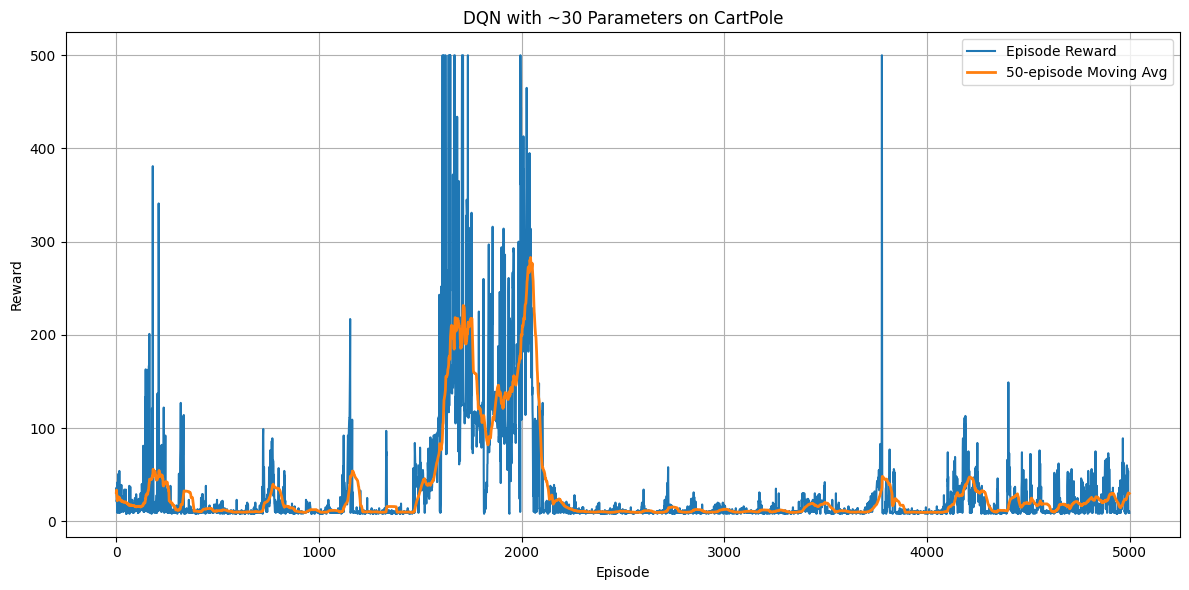

In [7]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# Replay buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# class MidSizedDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(MidSizedDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 16),   # 4*16 + 16 = 80
#             nn.ReLU(),
#             nn.Linear(16, 32),          # 16*32 + 32 = 544
#             nn.ReLU(),
#             nn.Linear(32, output_dim)   # 32*2 + 2 = 66
#         )

#     def forward(self, x):
#         return self.model(x)


# class ThreeHundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(ThreeHundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 10),  # 4*10 + 10 = 50
#             nn.ReLU(),
#             nn.Linear(10, 20),         # 10*20 + 20 = 220
#             nn.ReLU(),
#             nn.Linear(20, output_dim)  # 20*2 + 2 = 42
#         )

#     def forward(self, x):
#         return self.model(x)

# class HundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(HundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 5),   # 25 params
#             nn.ReLU(),
#             nn.Linear(5, 8),           # 48 params
#             nn.ReLU(),
#             nn.Linear(8, output_dim)   # 18 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class FiftyParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(FiftyParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 15 params
#             nn.ReLU(),
#             nn.Linear(3, 5),           # 20 params
#             nn.ReLU(),
#             nn.Linear(5, output_dim)   # 12 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TwentyFourParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TwentyFourParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),  # 15 params
#             nn.ReLU(),
#             nn.Linear(3, output_dim)  # 8 params
#         )

#     def forward(self, x):
#         return self.model(x)

class TinyThirtySixDQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(TinyThirtySixDQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 2),   # 4x2 + 2 = 10
            nn.ReLU(),
            nn.Linear(2, 2),           # 2x2 + 2 = 6
            nn.ReLU(),
            nn.Linear(2, output_dim)   # 2x2 + 2 = 6
        )

    def forward(self, x):
        return self.model(x)


def choose_action(model, state, epsilon, output_dim):
    if random.random() < epsilon:
        return random.randint(0, output_dim - 1)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():  # ✅ Prevent autograd from tracking this
        return model(state).argmax().item()

def train():
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = TinyThirtySixDQN(input_dim, output_dim)
    target_net = TinyThirtySixDQN(input_dim, output_dim)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = 1.0
    epsilon_end = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 5
    rewards = []

    state, _ = env.reset()
    for _ in range(1000):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        state = next_state if not done else env.reset()[0]

    for episode in range(5000):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(500):
            action = choose_action(q_net, state, epsilon, output_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards_, next_states, dones = buffer.sample(batch_size)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    targets = rewards_ + gamma * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

        if episode % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())

        print(f"Episode {episode + 1}: Reward = {total_reward}")

        # Early stopping if the last 10 episodes average above 400
        if episode >= 10 and np.mean(rewards[-10:]) >= 400:
            print(f"✅ Early stopping: Avg reward over last 10 episodes = {np.mean(rewards[-10:]):.2f}")
            break

    env.close()
    return rewards

rewards = train()
print(rewards)
window = 50
moving_avg = [np.mean(rewards[i - window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode Reward")
plt.plot(moving_avg, label=f"{window}-episode Moving Avg", linewidth=2)
plt.title("DQN with ~30 Parameters on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Episode 1: Reward = 26.0
Episode 2: Reward = 18.0
Episode 3: Reward = 17.0
Episode 4: Reward = 36.0
Episode 5: Reward = 64.0
Episode 6: Reward = 20.0
Episode 7: Reward = 9.0
Episode 8: Reward = 18.0
Episode 9: Reward = 22.0
Episode 10: Reward = 15.0
Episode 11: Reward = 36.0
Episode 12: Reward = 22.0
Episode 13: Reward = 11.0
Episode 14: Reward = 15.0
Episode 15: Reward = 12.0
Episode 16: Reward = 12.0
Episode 17: Reward = 15.0
Episode 18: Reward = 22.0
Episode 19: Reward = 16.0
Episode 20: Reward = 27.0
Episode 21: Reward = 45.0
Episode 22: Reward = 15.0
Episode 23: Reward = 15.0
Episode 24: Reward = 18.0
Episode 25: Reward = 28.0
Episode 26: Reward = 10.0
Episode 27: Reward = 14.0
Episode 28: Reward = 74.0
Episode 29: Reward = 13.0
Episode 30: Reward = 15.0
Episode 31: Reward = 16.0
Episode 32: Reward = 41.0
Episode 33: Reward = 16.0
Episode 34: Reward = 9.0
Episode 35: Reward = 16.0
Episode 36: Reward = 24.0
Episode 37: Reward = 13.0
Episode 38: Reward = 16.0
Episode 39: Reward = 16

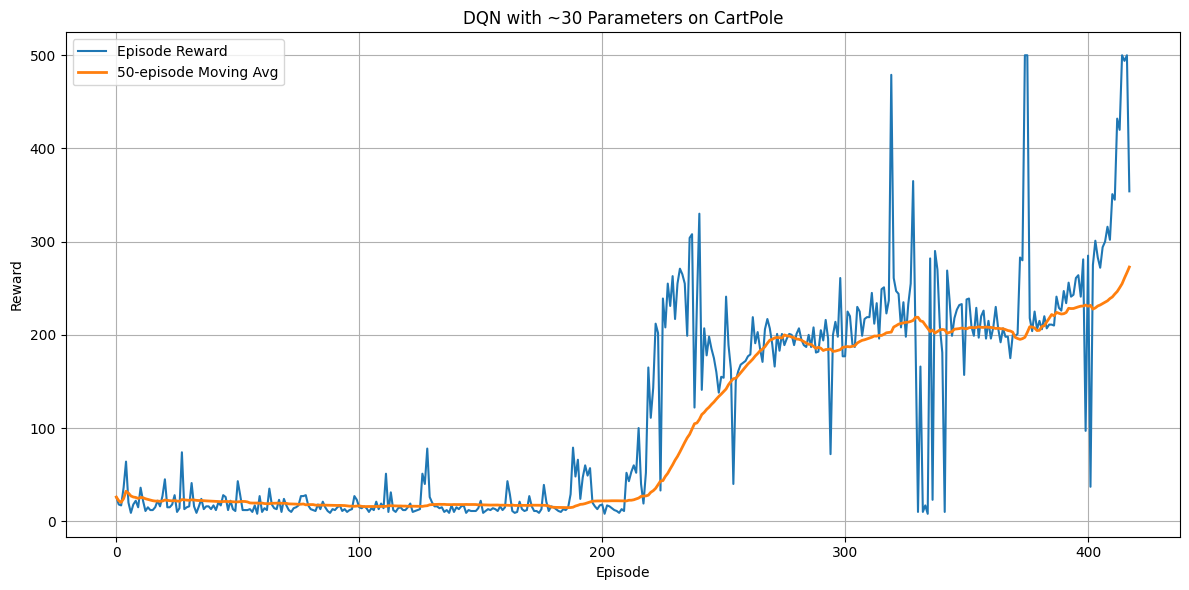

In [10]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# Replay buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# class MidSizedDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(MidSizedDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 16),   # 4*16 + 16 = 80
#             nn.ReLU(),
#             nn.Linear(16, 32),          # 16*32 + 32 = 544
#             nn.ReLU(),
#             nn.Linear(32, output_dim)   # 32*2 + 2 = 66
#         )

#     def forward(self, x):
#         return self.model(x)


# class ThreeHundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(ThreeHundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 10),  # 4*10 + 10 = 50
#             nn.ReLU(),
#             nn.Linear(10, 20),         # 10*20 + 20 = 220
#             nn.ReLU(),
#             nn.Linear(20, output_dim)  # 20*2 + 2 = 42
#         )

#     def forward(self, x):
#         return self.model(x)

# class HundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(HundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 5),   # 25 params
#             nn.ReLU(),
#             nn.Linear(5, 8),           # 48 params
#             nn.ReLU(),
#             nn.Linear(8, output_dim)   # 18 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class FiftyParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(FiftyParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 15 params
#             nn.ReLU(),
#             nn.Linear(3, 5),           # 20 params
#             nn.ReLU(),
#             nn.Linear(5, output_dim)   # 12 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TwentyFourParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TwentyFourParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),  # 15 params
#             nn.ReLU(),
#             nn.Linear(3, output_dim)  # 8 params
#         )

#     def forward(self, x):
#         return self.model(x)

class TinyThirtySixDQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(TinyThirtySixDQN, self).__init__()
        self.model = nn.Sequential(
            # nn.Linear(input_dim, 3),   # 4x3 + 3 = 15
            # nn.ReLU(),
            # nn.Linear(3, 2),           # 3x2 + 2 = 8
            # nn.ReLU(),
            # nn.Linear(2, output_dim)   # 2x2 + 2 = 6
            # CHANGED BY BRANDON
            nn.Linear(input_dim, 4),   # 4x4 + 4 = 20
            nn.ReLU(),
            nn.Linear(4, 2),           # 4x2 + 2 = 10
            nn.ReLU(),
            nn.Linear(2, output_dim)   # 2x2 + 2 = 6
        )

    def forward(self, x):
        return self.model(x)


def choose_action(model, state, epsilon, output_dim):
    if random.random() < epsilon:
        return random.randint(0, output_dim - 1)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():  # ✅ Prevent autograd from tracking this
        return model(state).argmax().item()

def train():
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = TinyThirtySixDQN(input_dim, output_dim)
    target_net = TinyThirtySixDQN(input_dim, output_dim)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = 1.0
    epsilon_end = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 5
    rewards = []

    state, _ = env.reset()
    for _ in range(1000):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        state = next_state if not done else env.reset()[0]

    for episode in range(2000):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(500):
            action = choose_action(q_net, state, epsilon, output_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards_, next_states, dones = buffer.sample(batch_size)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    targets = rewards_ + gamma * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

        if episode % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())

        print(f"Episode {episode + 1}: Reward = {total_reward}")

        # Early stopping if the last 10 episodes average above 400
        if episode >= 10 and np.mean(rewards[-10:]) >= 400:
            print(f"✅ Early stopping: Avg reward over last 10 episodes = {np.mean(rewards[-10:]):.2f}")
            break

    env.close()
    return rewards

rewards = train()
print(rewards)
window = 50
moving_avg = [np.mean(rewards[i - window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode Reward")
plt.plot(moving_avg, label=f"{window}-episode Moving Avg", linewidth=2)
plt.title("DQN with ~30 Parameters on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Episode 1: Reward = 16.0
Episode 2: Reward = 16.0
Episode 3: Reward = 22.0
Episode 4: Reward = 35.0
Episode 5: Reward = 27.0
Episode 6: Reward = 14.0
Episode 7: Reward = 14.0
Episode 8: Reward = 62.0
Episode 9: Reward = 16.0
Episode 10: Reward = 26.0
Episode 11: Reward = 18.0
Episode 12: Reward = 10.0
Episode 13: Reward = 20.0
Episode 14: Reward = 40.0
Episode 15: Reward = 13.0
Episode 16: Reward = 17.0
Episode 17: Reward = 11.0
Episode 18: Reward = 13.0
Episode 19: Reward = 37.0
Episode 20: Reward = 39.0
Episode 21: Reward = 33.0
Episode 22: Reward = 37.0
Episode 23: Reward = 14.0
Episode 24: Reward = 16.0
Episode 25: Reward = 16.0
Episode 26: Reward = 17.0
Episode 27: Reward = 34.0
Episode 28: Reward = 42.0
Episode 29: Reward = 45.0
Episode 30: Reward = 17.0
Episode 31: Reward = 31.0
Episode 32: Reward = 28.0
Episode 33: Reward = 40.0
Episode 34: Reward = 24.0
Episode 35: Reward = 43.0
Episode 36: Reward = 43.0
Episode 37: Reward = 38.0
Episode 38: Reward = 28.0
Episode 39: Reward = 

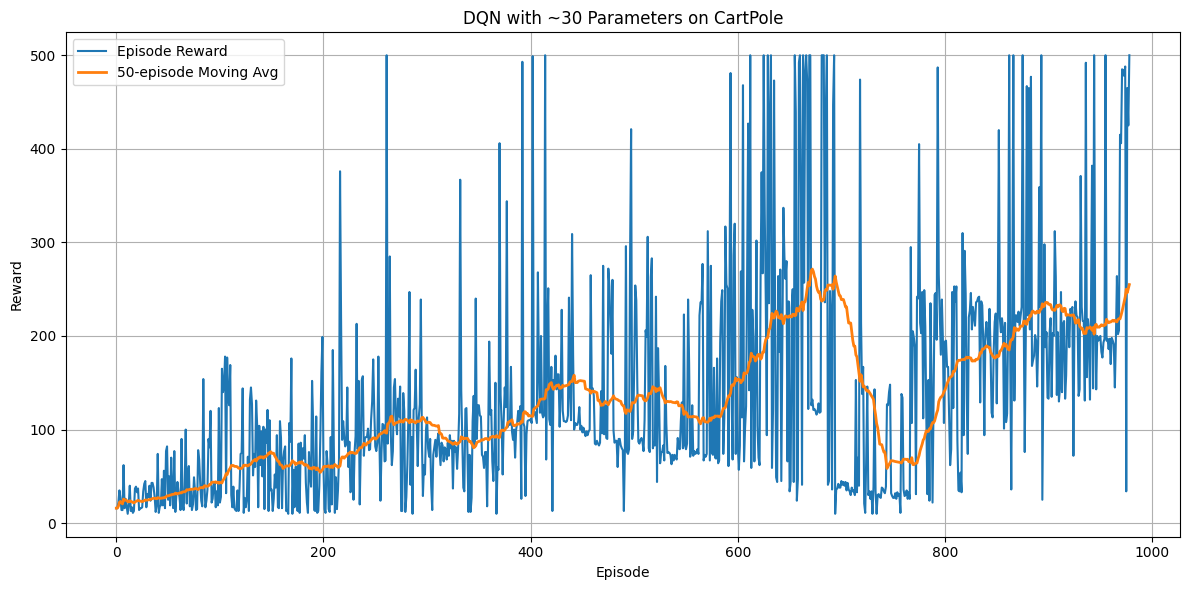

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# Replay buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# class MidSizedDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(MidSizedDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 16),   # 4*16 + 16 = 80
#             nn.ReLU(),
#             nn.Linear(16, 32),          # 16*32 + 32 = 544
#             nn.ReLU(),
#             nn.Linear(32, output_dim)   # 32*2 + 2 = 66
#         )

#     def forward(self, x):
#         return self.model(x)


# class ThreeHundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(ThreeHundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 10),  # 4*10 + 10 = 50
#             nn.ReLU(),
#             nn.Linear(10, 20),         # 10*20 + 20 = 220
#             nn.ReLU(),
#             nn.Linear(20, output_dim)  # 20*2 + 2 = 42
#         )

#     def forward(self, x):
#         return self.model(x)

# class HundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(HundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 5),   # 25 params
#             nn.ReLU(),
#             nn.Linear(5, 8),           # 48 params
#             nn.ReLU(),
#             nn.Linear(8, output_dim)   # 18 params
#         )

#     def forward(self, x):
#         return self.model(x)

class FiftyParamDQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FiftyParamDQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 3),   # 15 params
            nn.ReLU(),
            nn.Linear(3, 5),           # 20 params
            nn.ReLU(),
            nn.Linear(5, output_dim)   # 12 params
        )

    def forward(self, x):
        return self.model(x)

# class TwentyFourParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TwentyFourParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),  # 15 params
#             nn.ReLU(),
#             nn.Linear(3, output_dim)  # 8 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TinyThirtySixDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TinyThirtySixDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 4x3 + 3 = 15
#             nn.ReLU(),
#             nn.Linear(3, 2),           # 3x2 + 2 = 8
#             nn.ReLU(),
#             nn.Linear(2, output_dim)   # 2x2 + 2 = 6
#         )

#     def forward(self, x):
#         return self.model(x)


def choose_action(model, state, epsilon, output_dim):
    if random.random() < epsilon:
        return random.randint(0, output_dim - 1)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():  # ✅ Prevent autograd from tracking this
        return model(state).argmax().item()

def train():
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = FiftyParamDQN(input_dim, output_dim)
    target_net = FiftyParamDQN(input_dim, output_dim)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = 1.0
    epsilon_end = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 5
    rewards = []

    state, _ = env.reset()
    for _ in range(1000):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        state = next_state if not done else env.reset()[0]

    for episode in range(2000):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(500):
            action = choose_action(q_net, state, epsilon, output_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards_, next_states, dones = buffer.sample(batch_size)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    targets = rewards_ + gamma * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

        if episode % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())

        print(f"Episode {episode + 1}: Reward = {total_reward}")

        # Early stopping if the last 10 episodes average above 400
        if episode >= 10 and np.mean(rewards[-10:]) >= 400:
            print(f"✅ Early stopping: Avg reward over last 10 episodes = {np.mean(rewards[-10:]):.2f}")
            break

    env.close()
    return rewards

rewards = train()
window = 50
moving_avg = [np.mean(rewards[i - window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode Reward")
plt.plot(moving_avg, label=f"{window}-episode Moving Avg", linewidth=2)
plt.title("DQN with ~30 Parameters on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Episode 1: Reward = 9.0
Episode 2: Reward = 40.0
Episode 3: Reward = 15.0
Episode 4: Reward = 18.0
Episode 5: Reward = 23.0
Episode 6: Reward = 14.0
Episode 7: Reward = 11.0
Episode 8: Reward = 13.0
Episode 9: Reward = 16.0
Episode 10: Reward = 21.0
Episode 11: Reward = 21.0
Episode 12: Reward = 22.0
Episode 13: Reward = 18.0
Episode 14: Reward = 20.0
Episode 15: Reward = 23.0
Episode 16: Reward = 23.0
Episode 17: Reward = 18.0
Episode 18: Reward = 32.0
Episode 19: Reward = 16.0
Episode 20: Reward = 12.0
Episode 21: Reward = 18.0
Episode 22: Reward = 58.0
Episode 23: Reward = 19.0
Episode 24: Reward = 13.0
Episode 25: Reward = 55.0
Episode 26: Reward = 24.0
Episode 27: Reward = 37.0
Episode 28: Reward = 44.0
Episode 29: Reward = 32.0
Episode 30: Reward = 26.0
Episode 31: Reward = 22.0
Episode 32: Reward = 18.0
Episode 33: Reward = 45.0
Episode 34: Reward = 14.0
Episode 35: Reward = 23.0
Episode 36: Reward = 12.0
Episode 37: Reward = 18.0
Episode 38: Reward = 29.0
Episode 39: Reward = 6

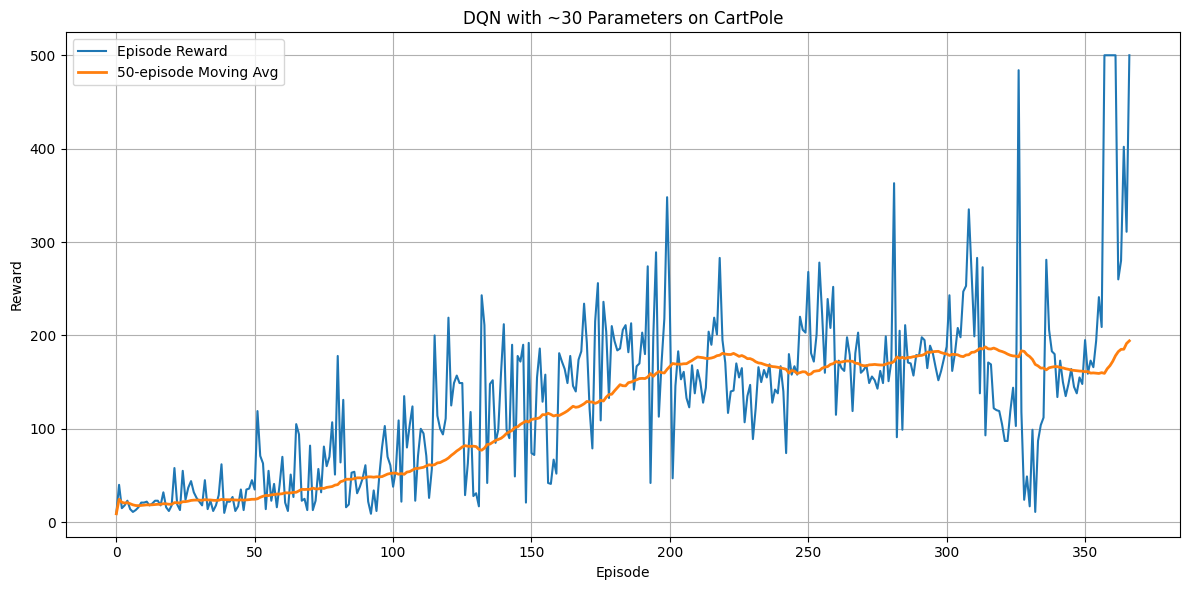

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# Replay buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# class MidSizedDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(MidSizedDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 16),   # 4*16 + 16 = 80
#             nn.ReLU(),
#             nn.Linear(16, 32),          # 16*32 + 32 = 544
#             nn.ReLU(),
#             nn.Linear(32, output_dim)   # 32*2 + 2 = 66
#         )

#     def forward(self, x):
#         return self.model(x)


# class ThreeHundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(ThreeHundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 10),  # 4*10 + 10 = 50
#             nn.ReLU(),
#             nn.Linear(10, 20),         # 10*20 + 20 = 220
#             nn.ReLU(),
#             nn.Linear(20, output_dim)  # 20*2 + 2 = 42
#         )

#     def forward(self, x):
#         return self.model(x)

class HundredParamDQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(HundredParamDQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 5),   # 25 params
            nn.ReLU(),
            nn.Linear(5, 8),           # 48 params
            nn.ReLU(),
            nn.Linear(8, output_dim)   # 18 params
        )

    def forward(self, x):
        return self.model(x)

# class FiftyParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(FiftyParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 15 params
#             nn.ReLU(),
#             nn.Linear(3, 5),           # 20 params
#             nn.ReLU(),
#             nn.Linear(5, output_dim)   # 12 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TwentyFourParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TwentyFourParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),  # 15 params
#             nn.ReLU(),
#             nn.Linear(3, output_dim)  # 8 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TinyThirtySixDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TinyThirtySixDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 4x3 + 3 = 15
#             nn.ReLU(),
#             nn.Linear(3, 2),           # 3x2 + 2 = 8
#             nn.ReLU(),
#             nn.Linear(2, output_dim)   # 2x2 + 2 = 6
#         )

#     def forward(self, x):
#         return self.model(x)


def choose_action(model, state, epsilon, output_dim):
    if random.random() < epsilon:
        return random.randint(0, output_dim - 1)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():  # ✅ Prevent autograd from tracking this
        return model(state).argmax().item()

def train():
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = HundredParamDQN(input_dim, output_dim)
    target_net = HundredParamDQN(input_dim, output_dim)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = 1.0
    epsilon_end = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 5
    rewards = []

    state, _ = env.reset()
    for _ in range(1000):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        state = next_state if not done else env.reset()[0]

    for episode in range(2000):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(500):
            action = choose_action(q_net, state, epsilon, output_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards_, next_states, dones = buffer.sample(batch_size)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    targets = rewards_ + gamma * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

        if episode % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())

        print(f"Episode {episode + 1}: Reward = {total_reward}")

        # Early stopping if the last 10 episodes average above 400
        if episode >= 10 and np.mean(rewards[-10:]) >= 400:
            print(f"✅ Early stopping: Avg reward over last 10 episodes = {np.mean(rewards[-10:]):.2f}")
            break

    env.close()
    return rewards

rewards = train()
window = 50
moving_avg = [np.mean(rewards[i - window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode Reward")
plt.plot(moving_avg, label=f"{window}-episode Moving Avg", linewidth=2)
plt.title("DQN with ~30 Parameters on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Episode 1: Reward = 18.0
Episode 2: Reward = 51.0
Episode 3: Reward = 49.0
Episode 4: Reward = 12.0
Episode 5: Reward = 15.0
Episode 6: Reward = 19.0
Episode 7: Reward = 25.0
Episode 8: Reward = 13.0
Episode 9: Reward = 13.0
Episode 10: Reward = 19.0
Episode 11: Reward = 23.0
Episode 12: Reward = 53.0
Episode 13: Reward = 54.0
Episode 14: Reward = 15.0
Episode 15: Reward = 16.0
Episode 16: Reward = 19.0
Episode 17: Reward = 19.0
Episode 18: Reward = 21.0
Episode 19: Reward = 11.0
Episode 20: Reward = 11.0
Episode 21: Reward = 28.0
Episode 22: Reward = 12.0
Episode 23: Reward = 25.0
Episode 24: Reward = 12.0
Episode 25: Reward = 16.0
Episode 26: Reward = 25.0
Episode 27: Reward = 30.0
Episode 28: Reward = 14.0
Episode 29: Reward = 103.0
Episode 30: Reward = 24.0
Episode 31: Reward = 22.0
Episode 32: Reward = 20.0
Episode 33: Reward = 12.0
Episode 34: Reward = 56.0
Episode 35: Reward = 24.0
Episode 36: Reward = 60.0
Episode 37: Reward = 32.0
Episode 38: Reward = 34.0
Episode 39: Reward =

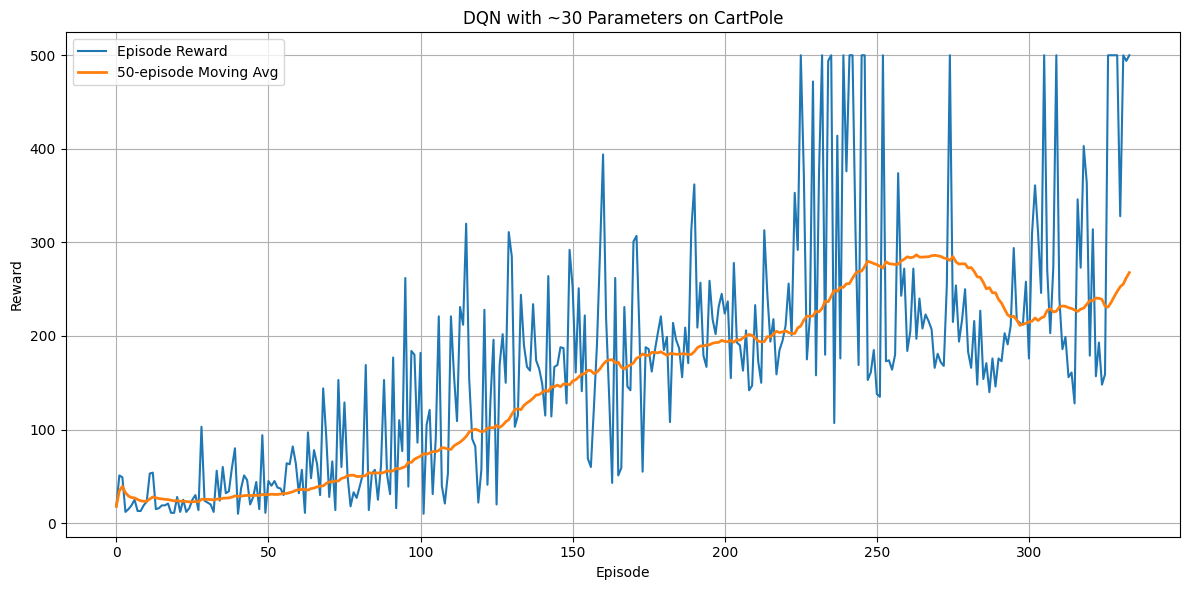

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# Replay buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# class MidSizedDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(MidSizedDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 16),   # 4*16 + 16 = 80
#             nn.ReLU(),
#             nn.Linear(16, 32),          # 16*32 + 32 = 544
#             nn.ReLU(),
#             nn.Linear(32, output_dim)   # 32*2 + 2 = 66
#         )

#     def forward(self, x):
#         return self.model(x)


# class ThreeHundredParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(ThreeHundredParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 10),  # 4*10 + 10 = 50
#             nn.ReLU(),
#             nn.Linear(10, 20),         # 10*20 + 20 = 220
#             nn.ReLU(),
#             nn.Linear(20, output_dim)  # 20*2 + 2 = 42
#         )

#     def forward(self, x):
#         return self.model(x)

class HundredParamDQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(HundredParamDQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 6),   # 4*6+6  = 30 params
            nn.ReLU(),
            nn.Linear(6, 9),           # 6*11+11  = 77 params
            nn.ReLU(),
            nn.Linear(9, output_dim)   # 11*2+2 = 24 params
        )

    def forward(self, x):
        return self.model(x)

# class FiftyParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(FiftyParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 15 params
#             nn.ReLU(),
#             nn.Linear(3, 5),           # 20 params
#             nn.ReLU(),
#             nn.Linear(5, output_dim)   # 12 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TwentyFourParamDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TwentyFourParamDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),  # 15 params
#             nn.ReLU(),
#             nn.Linear(3, output_dim)  # 8 params
#         )

#     def forward(self, x):
#         return self.model(x)

# class TinyThirtySixDQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TinyThirtySixDQN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 3),   # 4x3 + 3 = 15
#             nn.ReLU(),
#             nn.Linear(3, 2),           # 3x2 + 2 = 8
#             nn.ReLU(),
#             nn.Linear(2, output_dim)   # 2x2 + 2 = 6
#         )

#     def forward(self, x):
#         return self.model(x)


def choose_action(model, state, epsilon, output_dim):
    if random.random() < epsilon:
        return random.randint(0, output_dim - 1)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():  # ✅ Prevent autograd from tracking this
        return model(state).argmax().item()

def train():
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = HundredParamDQN(input_dim, output_dim)
    target_net = HundredParamDQN(input_dim, output_dim)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = 1.0
    epsilon_end = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 5
    rewards = []

    state, _ = env.reset()
    for _ in range(1000):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        state = next_state if not done else env.reset()[0]

    for episode in range(2000):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(500):
            action = choose_action(q_net, state, epsilon, output_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards_, next_states, dones = buffer.sample(batch_size)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    targets = rewards_ + gamma * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

        if episode % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())

        print(f"Episode {episode + 1}: Reward = {total_reward}")

        # Early stopping if the last 10 episodes average above 400
        if episode >= 10 and np.mean(rewards[-10:]) >= 400:
            print(f"✅ Early stopping: Avg reward over last 10 episodes = {np.mean(rewards[-10:]):.2f}")
            break

    env.close()
    return rewards

rewards = train()
window = 50
moving_avg = [np.mean(rewards[i - window:i]) if i >= window else np.mean(rewards[:i+1]) for i in range(len(rewards))]

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Episode Reward")
plt.plot(moving_avg, label=f"{window}-episode Moving Avg", linewidth=2)
plt.title("DQN with ~30 Parameters on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Classical Policy Gradients

Episode 1: Total reward = 32.0, Recent avg = 0.00
Episode 2: Total reward = 36.0, Recent avg = 0.00
Episode 3: Total reward = 26.0, Recent avg = 0.00
Episode 4: Total reward = 16.0, Recent avg = 0.00
Episode 5: Total reward = 14.0, Recent avg = 0.00
Episode 6: Total reward = 15.0, Recent avg = 0.00
Episode 7: Total reward = 37.0, Recent avg = 0.00
Episode 8: Total reward = 19.0, Recent avg = 0.00
Episode 9: Total reward = 18.0, Recent avg = 0.00
Episode 10: Total reward = 14.0, Recent avg = 22.70
Episode 11: Total reward = 17.0, Recent avg = 21.20
Episode 12: Total reward = 41.0, Recent avg = 21.70
Episode 13: Total reward = 12.0, Recent avg = 20.30
Episode 14: Total reward = 11.0, Recent avg = 19.80
Episode 15: Total reward = 30.0, Recent avg = 21.40
Episode 16: Total reward = 11.0, Recent avg = 21.00
Episode 17: Total reward = 20.0, Recent avg = 19.30
Episode 18: Total reward = 29.0, Recent avg = 20.30
Episode 19: Total reward = 18.0, Recent avg = 20.30
Episode 20: Total reward = 13.

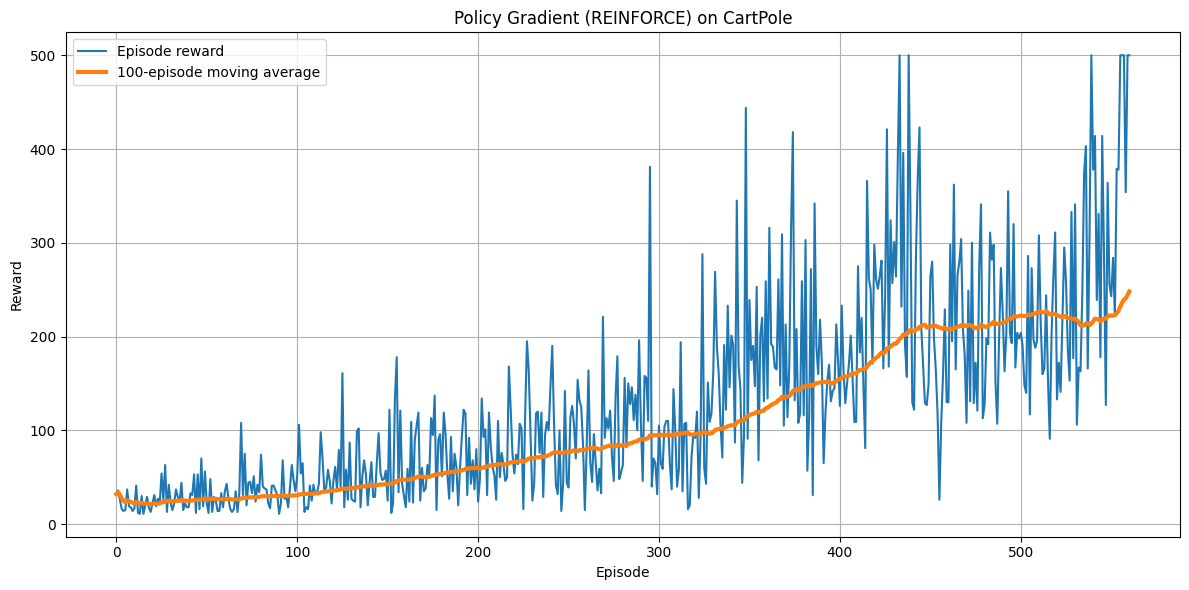

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_size, act_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, act_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

def compute_returns(rewards, gamma=0.99):
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

def train(env, policy, optimizer, episodes=10000, max_steps=500, gamma=0.99, early_stop_reward=400, early_stop_window=10):
    episode_rewards = []

    for episode in range(episodes):
        obs, _ = env.reset()
        obs = torch.tensor(obs, dtype=torch.float32)
        log_probs = []
        rewards = []
        total_reward = 0

        for _ in range(max_steps):
            probs = policy(obs)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))

            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            rewards.append(reward)
            total_reward += reward

            obs = torch.tensor(next_obs, dtype=torch.float32)

            if done:
                break

        returns = compute_returns(rewards, gamma)
        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.min()) / (returns.max() - returns.min() + 1e-8)

        entropy = -torch.sum(probs * torch.log(probs + 1e-8))
        loss = -torch.sum(torch.stack(log_probs) * returns) - 0.01 * entropy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_rewards.append(total_reward)

        # Moving average window for diagnostics and early stop
        recent_avg = np.mean(episode_rewards[-early_stop_window:]) if len(episode_rewards) >= early_stop_window else 0
        print(f"Episode {episode + 1}: Total reward = {total_reward}, Recent avg = {recent_avg:.2f}")

        if recent_avg >= early_stop_reward:
            print(f"✅ Early stopping at episode {episode+1} with average reward: {recent_avg:.2f}")
            break

    return episode_rewards

def plot_rewards(rewards, window=100):
    smoothed = []
    for i in range(len(rewards)):
        start = max(0, i - window + 1)
        avg = np.mean(rewards[start:i+1])
        smoothed.append(avg)

    plt.figure(figsize=(12, 6))
    plt.plot(rewards, label="Episode reward")
    plt.plot(smoothed, label=f"{window}-episode moving average", linewidth=3)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Policy Gradient (REINFORCE) on CartPole")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy = PolicyNetwork(obs_dim, hidden_size=128, act_dim=act_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.001)

    rewards = train(env, policy, optimizer, episodes=1000)
    plot_rewards(rewards)
